# Temas Tratados en el Trabajo Práctico 6

* Modelado de problemas en espacios de estado.

* Algoritmos de planificación hacia adelante y hacia atrás.

* Representación y solución de problemas descritos en lenguaje STRIPS.

* Algoritmo GRAPHPLAN.

* Planificación con restricciones de tiempo y recursos.

* Caminos críticos y tiempos de relajación.

## Ejercicios Teóricos

1. ¿En qué tipo de algoritmos se basa un planificador para encontrar el mejor camino a un estado solución?

Los planificadores se basan en algoritmos de busqueda (progresión, regresión, planificación ordenada parcial o GRAPHPLAN), que son adaptaciones de los métodos de búsqueda en espacios de estados para encontrar la mejor secuencia de acciones que lleve al estado objetivo.


2. ¿Qué tres elementos se encuentran dentro de una acción formulada en lenguaje STRIPS? Describa brevemente qué función cumple cada uno.

Una acción en STRIPS (STANDFORD RESEARCH INSTITUTE PROBLEM SOLVER) se compone de:

Nombre y parámetros:de los que depende la acción (qué acción y sobre quién actúa). Ejemplo:  Acción (volar (p,desde,hasta))

Precondiciones: qué debe cumplirse antes. Ejemplo: En(p,desde) ^ avión(p) ^ aeropuerto(desde) ^ aeropuerto(hasta)

Efectos: cómo cambia el mundo después. Ejemplo: ¬ En(p,desde) ^ En(p,hasta)

3. Describa las ventajas y desventajas de desarrollar un algoritmo de planificación hacia adelante y hacia atrás en el espacio de estados.


🔹 Planificación hacia adelante (progresión)

Cómo funciona:
Parte del estado inicial y aplica todas las acciones posibles hasta encontrar un estado que cumpla con el objetivo.

Ventajas:

Conceptualmente simple y directa.

Se pueden usar los algoritmos clásicos de búsqueda en grafos (BFS, DFS, A*, etc.).

Fácil de implementar.

Desventajas:

Ineficaz en la práctica, porque considera todas las acciones posibles, incluso las irrelevantes.

Puede generar un espacio de búsqueda muy grande y redundante.

Dificultad para encontrar planes óptimos en problemas complejos.

🔹 Planificación hacia atrás (regresión)

Cómo funciona:
Parte del estado objetivo e intenta encontrar los estados predecesores que permitirían alcanzarlo, aplicando acciones relevantes hacia atrás.

Ventajas:

Más eficiente, porque se centra solo en acciones relevantes al objetivo.

Permite descartar rápidamente acciones que no contribuyen a alcanzar la meta.

Reduce el tamaño del espacio de búsqueda en comparación con la progresión.

Desventajas:

Difícil de implementar: no siempre es obvio cómo generar los estados predecesores.

Puede complicarse cuando los objetivos son múltiples o interactúan entre sí.


4. Considere el problema de ponerse uno mismo zapatos y medias. Aplique GRAPHPLAN a este problema y muestre la solución obtenida. Muestre el plan de orden parcial que es solución e indique cuántas linealizaciones diferentes existen para el plan de orden parcial.

GRAPHPLAN:
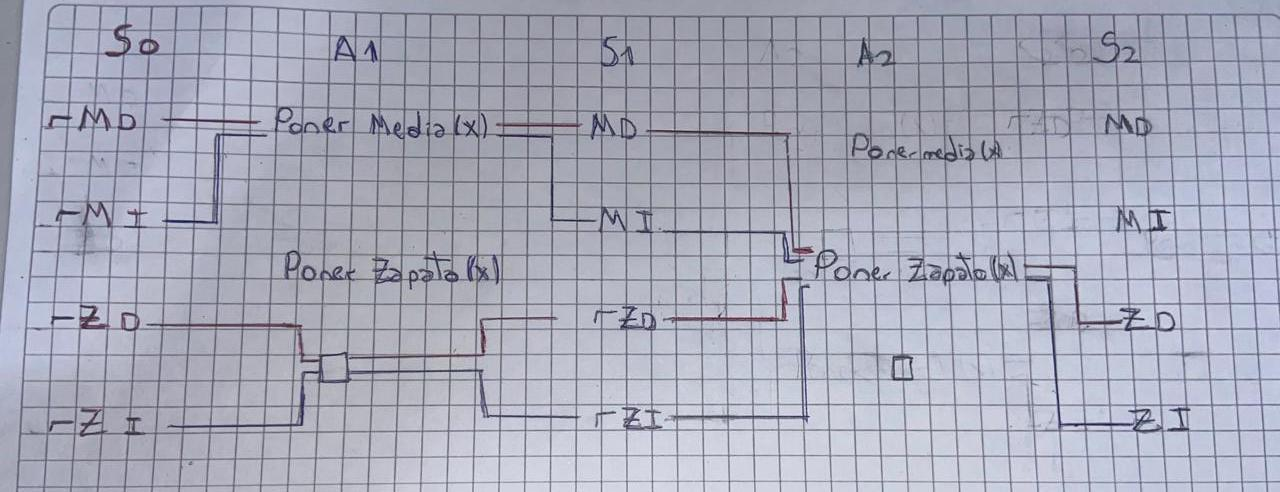

En nuestro ejemplo hay 6 linealización que forman el plan de orden total, siendo cada una un plan de orden parcial:
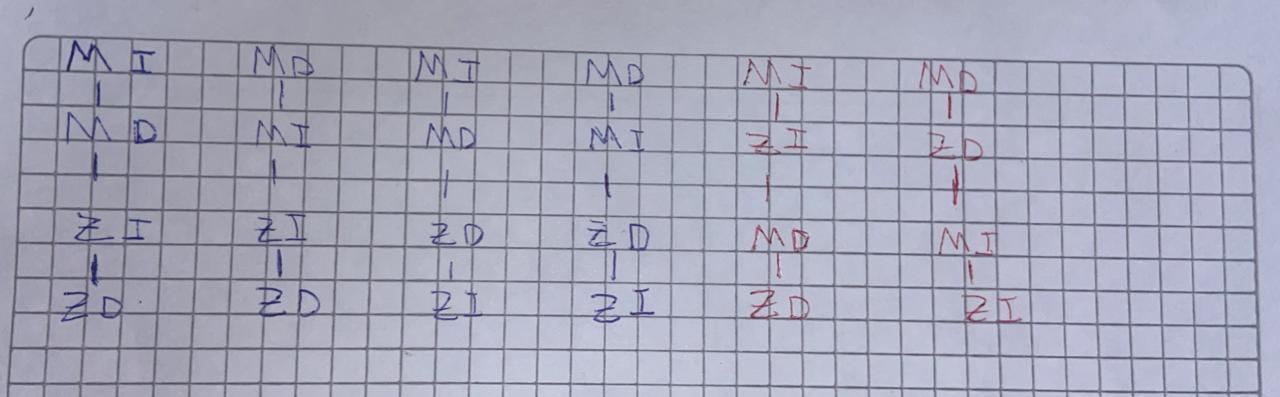

5. Se requiere ensamblar una máquina cuyas piezas están identificadas con las letras A, B, C, D y E. El tiempo que se tarda en ensamblar cada pieza es:

* A: 2 semanas

* B: 1 semana

* C: 4 semanas

* D: 3 semanas

* E: 5 semanas

    El orden de ensamblaje de cada pieza requiere que:

* A esté realizado antes que C

* B esté realizado antes que C

* B esté realizado antes que D

* C esté realizado antes que E

* D esté realizado antes que E

    Con esta información:

        5.1 Arme el Plan de Orden Parcial.

        5.2 Encuentre el Camino Crítico.

        5.3 Encuentre los tiempos de relajación.

        5.4 Dibuje un diagrama temporal indicando las tareas y los tiempos de relajación encontrados.

5.1) Plan de orden parcial: ACE, BCE,BDE
Inicio → {A, B} → {C, D} → E, con las relaciones indicadas (A y B paralelas al inicio; C espera A y B; D espera B; E espera C y D).
5.2) Camino Crítico: ACE con duración 2+4+5 = 11.
5.3) Con el pase hacia atrás (LS/LF):

A: LS=0, LF=2 → Slack = 0

B: LS=1, LF=2 → Slack = 1

C: LS=2, LF=6 → Slack = 0

D: LS=3, LF=6 → Slack = 2

E: LS=6, LF=11 → Slack = 0

Resumen de holguras:

A = 0, B = 1, C = 0, D = 2, E = 0 (semanas)
5.4)
5.4) ![imagen5](/home/vale/Escritorio/Trabajos practicos/tp6_5.png)
En la imagen se ven en naranja las dos semanas del proceso A, en celeste y verde la semana de B que puede empezar luego de la primera semana o en tiempo cero con A. Luego en amarillo se ve las 4 semanas de C. En azul están las 3 semanas de D comenzando en la semana 1 y en rojo marca el final de esas tres semanas si empezara en la semana 2. Por último, en rosa están las 6 semanas del proceso E.

## Ejercicios de Implementación

6. Suponga que tiene un robot de oficina capaz de moverse y tomar y depositar objetos. El robot solo puede tener un objeto a la vez, pero puede conseguir una *caja* en la que depositar varios objetos. Suponga que programa al robot para *ir a la tienda* a comprarle un *café* y en el camino de vuelta tome una *carta* del *buzón* de la oficina para para que se la traiga junto con el café. Describa en lenguaje STRIPS:

        6.1 El dominio del robot (nombre, predicados y acciones que puede hacer el robot).

        6.2 El problema que se quiere resolver (estado inicial, estado objetivo y objetos del mundo representados).

        6.3 Introduzca el código desarrollado en los puntos anteriores en el [planificador online](http://lcas.lincoln.ac.uk/fast-downward/) y obtenga el plan de acción que tomará el robot para cumplir lo solicitado.

(define (domain robot)
  (:requirements :strips)
  (:predicates 
    (room ?r)
    (object ?o)
    (at-robot ?r)
    (at ?o ?r)
    (free)          ; mano libre
    (has ?o)        ; llevando un objeto en la mano
    (has-box)       ; tiene/porta la caja (no ocupa la mano)
    (in-box ?o)     ; objeto está dentro de la caja
  )

  (:action move
    :parameters  (?from ?to)
    :precondition (and (room ?from) (room ?to) (at-robot ?from))
    :effect (and (at-robot ?to) (not (at-robot ?from)))
  )

  (:action pick
    :parameters (?o ?r)
    :precondition (and (object ?o) (room ?r) (at-robot ?r) (at ?o ?r) (free))
    :effect (and (has ?o) (not (at ?o ?r)) (not (free)))
  )

  (:action drop
    :parameters  (?o ?r)
    :precondition (and (object ?o) (room ?r) (at-robot ?r) (has ?o))
    :effect (and (at ?o ?r) (free) (not (has ?o)))
  )

  ; La caja no ocupa la mano: NO exige (free) y NO cambia (free)
  (:action take-box
    :parameters (?c ?r)
    :precondition (and (object ?c) (room ?r) (at-robot ?r) (at ?c ?r))
    :effect (and (has-box) (not (at ?c ?r)))
  )

  (:action put-in-box
    :parameters (?o ?r)
    :precondition (and (object ?o) (room ?r) (at-robot ?r) (has ?o) (has-box))
    :effect (and (in-box ?o) (free) (not (has ?o)))
  )

  (:action takeout-of-box
    :parameters (?o ?r)
    :precondition (and (object ?o) (room ?r) (at-robot ?r) (in-box ?o) (free))
    :effect (and (has ?o) (not (in-box ?o)) (not (free)))
  )
)


(define (problem bring-coffee-letter)
  (:domain robot)
  (:requirements :strips)

  (:objects
    office mail cofeeshop coffee letter box
  )

  (:init
    ; clasificaciones
    (room office) (room mail) (room cofeeshop)
    (object coffee) (object letter) (object box)

    ; estado inicial
    (at-robot office)
    (at box office)
    (at coffee cofeeshop)
    (at letter mail)
    (free)
  )

  (:goal (and
    (at coffee office)
    (at letter office)
  ))
)

No pudimos correr en Fast-Downward, esta sería la solución según chat GPT:

(take-box box office)
(move office cofeeshop)
(pick coffee cofeeshop)
(put-in-box coffee cofeeshop)
(move cofeeshop mail)
(pick letter mail)
(put-in-box letter mail)
(move mail office)
(takeout-of-box coffee office)
(takeout-of-box letter office)


![imagen](/home/vale/Escritorio/Trabajos practicos/tp6_5.jpeg)


# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)